In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

try:
    with sqlite3.connect(db_path) as conn:
        query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
        df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])
    
    df = df.set_index("timestamp").sort_index()
    multiplicadores = df['multiplicador'].tolist()
    print(f"Sucesso: {len(multiplicadores)} rodadas carregadas do banco de dados.")
    
    print("\nÚltimas 5 rodadas carregadas:")
    display(df.tail())

except Exception as e:
    print(f"Erro ao carregar dados: {e}")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
Sucesso: 105281 rodadas carregadas do banco de dados.

Últimas 5 rodadas carregadas:


,multiplicador
timestamp,
2026-01-12 10:59:18.988372,5.82
2026-01-12 10:59:37.730203,1.53
2026-01-12 11:00:04.503964,5.64
2026-01-12 11:00:29.862974,2.88
2026-01-12 11:00:44.898111,1.09


In [2]:
# --- CÉLULA 2: FUNÇÕES DE SIMULAÇÃO ---

def simular_124_classico(multiplicadores, banca=500, gatilho=6, target=1.99):
    """
    Simula Martingale 1-2-4 clássico (3 dobras).
    Quebra se 9+ baixas consecutivas.
    """
    parte = banca / 7  # 1+2+4 = 7
    dobras = {1: parte * 1, 2: parte * 2, 3: parte * 4}
    
    lucro_total = 0
    quebras = 0
    wins = {1: 0, 2: 0, 3: 0}
    entradas = 0
    historico = [0]
    
    i = 0
    while i < len(multiplicadores):
        lows = 0
        j = i
        while j < len(multiplicadores) and multiplicadores[j] < 2.0:
            lows += 1
            j += 1
        
        if lows >= gatilho:
            entradas += 1
            entrada = i + gatilho
            perdas = 0
            ganhou = False
            
            for dobra in [1, 2, 3]:
                pos = entrada + (dobra - 1)
                if pos >= len(multiplicadores):
                    break
                
                aposta = dobras[dobra]
                
                if multiplicadores[pos] >= target:
                    ganho = aposta * (target - 1) * 0.99  # 1% taxa
                    lucro_total += ganho - perdas
                    wins[dobra] += 1
                    ganhou = True
                    break
                else:
                    perdas += aposta
            
            if not ganhou:
                lucro_total -= banca
                quebras += 1
            
            historico.append(lucro_total)
        
        i = j if j > i else i + 1
    
    return {
        'lucro': lucro_total,
        'quebras': quebras,
        'wins': wins,
        'entradas': entradas,
        'taxa_win': sum(wins.values()) / entradas * 100 if entradas > 0 else 0,
        'historico': historico
    }


def simular_124124(multiplicadores, banca=500, gatilho=6, target=1.99, divisao='50/50'):
    """
    Simula Martingale 1-2-4-1-2-4 (6 dobras).
    Quebra apenas se 12+ baixas consecutivas.
    
    divisao: '50/50' ou '33/67' (ciclo1/ciclo2)
    """
    if divisao == '50/50':
        banca_c1 = banca / 2
        banca_c2 = banca / 2
    else:  # '33/67'
        banca_c1 = banca / 3
        banca_c2 = (banca * 2) / 3
    
    parte_c1 = banca_c1 / 7
    parte_c2 = banca_c2 / 7
    
    dobras = {
        1: parte_c1 * 1, 2: parte_c1 * 2, 3: parte_c1 * 4,
        4: parte_c2 * 1, 5: parte_c2 * 2, 6: parte_c2 * 4
    }
    
    lucro_total = 0
    quebras = 0
    wins = {d: 0 for d in range(1, 7)}
    entradas = 0
    historico = [0]
    
    i = 0
    while i < len(multiplicadores):
        lows = 0
        j = i
        while j < len(multiplicadores) and multiplicadores[j] < 2.0:
            lows += 1
            j += 1
        
        if lows >= gatilho:
            entradas += 1
            entrada = i + gatilho
            perdas = 0
            ganhou = False
            
            for dobra in range(1, 7):
                pos = entrada + (dobra - 1)
                if pos >= len(multiplicadores):
                    break
                
                aposta = dobras[dobra]
                
                if multiplicadores[pos] >= target:
                    ganho = aposta * (target - 1) * 0.99
                    lucro_total += ganho - perdas
                    wins[dobra] += 1
                    ganhou = True
                    break
                else:
                    perdas += aposta
            
            if not ganhou:
                lucro_total -= banca
                quebras += 1
            
            historico.append(lucro_total)
        
        i = j if j > i else i + 1
    
    return {
        'lucro': lucro_total,
        'quebras': quebras,
        'wins': wins,
        'entradas': entradas,
        'taxa_win': sum(wins.values()) / entradas * 100 if entradas > 0 else 0,
        'historico': historico
    }

print("✅ Funções de simulação carregadas!")

✅ Funções de simulação carregadas!


In [3]:
# --- CÉLULA 3: COMPARAÇÃO DAS ESTRATÉGIAS ---

print("="*70)
print("🎰 COMPARAÇÃO DAS ESTRATÉGIAS")
print("="*70)
print(f"Dados: {len(multiplicadores):,} rodadas")
print(f"Banca: R$ 500,00")
print(f"Target: 1.99x")
print(f"Gatilho: 6 baixas")

# Simular
res_124 = simular_124_classico(multiplicadores)
res_5050 = simular_124124(multiplicadores, divisao='50/50')
res_3367 = simular_124124(multiplicadores, divisao='33/67')

print("\n" + "-"*70)
print("📊 ESTRATÉGIA 1-2-4 CLÁSSICA (3 dobras)")
print("-"*70)
print(f"  Entradas: {res_124['entradas']:,}")
print(f"  Vitórias: D1={res_124['wins'][1]}, D2={res_124['wins'][2]}, D3={res_124['wins'][3]}")
print(f"  Quebras: {res_124['quebras']}")
print(f"  Taxa de Vitória: {res_124['taxa_win']:.1f}%")
print(f"  💰 LUCRO TOTAL: R$ {res_124['lucro']:,.2f}")

print("\n" + "-"*70)
print("🚀 ESTRATÉGIA 1-2-4-1-2-4 (6 dobras) - Divisão 50/50")
print("-"*70)
print(f"  Entradas: {res_5050['entradas']:,}")
print(f"  Ciclo 1: D1={res_5050['wins'][1]}, D2={res_5050['wins'][2]}, D3={res_5050['wins'][3]}")
print(f"  Ciclo 2: D4={res_5050['wins'][4]}, D5={res_5050['wins'][5]}, D6={res_5050['wins'][6]}")
print(f"  Quebras: {res_5050['quebras']}")
print(f"  Taxa de Vitória: {res_5050['taxa_win']:.1f}%")
print(f"  💰 LUCRO TOTAL: R$ {res_5050['lucro']:,.2f}")

print("\n" + "-"*70)
print("🚀 ESTRATÉGIA 1-2-4-1-2-4 (6 dobras) - Divisão 33/67 (ATUAL)")
print("-"*70)
print(f"  Entradas: {res_3367['entradas']:,}")
print(f"  Ciclo 1: D1={res_3367['wins'][1]}, D2={res_3367['wins'][2]}, D3={res_3367['wins'][3]}")
print(f"  Ciclo 2: D4={res_3367['wins'][4]}, D5={res_3367['wins'][5]}, D6={res_3367['wins'][6]}")
print(f"  Quebras: {res_3367['quebras']}")
print(f"  Taxa de Vitória: {res_3367['taxa_win']:.1f}%")
print(f"  💰 LUCRO TOTAL: R$ {res_3367['lucro']:,.2f}")

🎰 COMPARAÇÃO DAS ESTRATÉGIAS
Dados: 105,281 rodadas
Banca: R$ 500,00
Target: 1.99x
Gatilho: 6 baixas

----------------------------------------------------------------------
📊 ESTRATÉGIA 1-2-4 CLÁSSICA (3 dobras)
----------------------------------------------------------------------
  Entradas: 1,271
  Vitórias: D1=682, D2=317, D3=154
  Quebras: 118
  Taxa de Vitória: 90.7%
  💰 LUCRO TOTAL: R$ 20,610.94

----------------------------------------------------------------------
🚀 ESTRATÉGIA 1-2-4-1-2-4 (6 dobras) - Divisão 50/50
----------------------------------------------------------------------
  Entradas: 1,271
  Ciclo 1: D1=682, D2=317, D3=154
  Ciclo 2: D4=68, D5=31, D6=13
  Quebras: 6
  Taxa de Vitória: 99.5%
  💰 LUCRO TOTAL: R$ 12,676.12

----------------------------------------------------------------------
🚀 ESTRATÉGIA 1-2-4-1-2-4 (6 dobras) - Divisão 33/67 (ATUAL)
----------------------------------------------------------------------
  Entradas: 1,271
  Ciclo 1: D1=682, D2=317, 

In [4]:
# --- CÉLULA 4: TABELA COMPARATIVA ---

print("\n" + "="*70)
print("📈 RESUMO COMPARATIVO")
print("="*70)

comparativo = pd.DataFrame({
    'Estratégia': ['1-2-4 Clássico', '1-2-4-1-2-4 (50/50)', '1-2-4-1-2-4 (33/67)'],
    'Lucro': [res_124['lucro'], res_5050['lucro'], res_3367['lucro']],
    'Quebras': [res_124['quebras'], res_5050['quebras'], res_3367['quebras']],
    'Entradas': [res_124['entradas'], res_5050['entradas'], res_3367['entradas']],
    'Win Rate': [res_124['taxa_win'], res_5050['taxa_win'], res_3367['taxa_win']]
})
display(comparativo)

# Diferença entre divisões
diferenca = res_5050['lucro'] - res_3367['lucro']
diferenca_pct = (res_5050['lucro'] / res_3367['lucro'] - 1) * 100

print(f"\n💡 DIFERENÇA 50/50 vs 33/67:")
print(f"   + R$ {diferenca:,.2f} ({diferenca_pct:+.1f}%)")


📈 RESUMO COMPARATIVO


,Estratégia,Lucro,Quebras,Entradas,Win Rate
0,1-2-4 Clássico,20610.942857,118,1271,90.715972
1,1-2-4-1-2-4 (50/50),12676.121429,6,1271,99.527931
2,1-2-4-1-2-4 (33/67),10031.180952,6,1271,99.527931



💡 DIFERENÇA 50/50 vs 33/67:
   + R$ 2,644.94 (+26.4%)


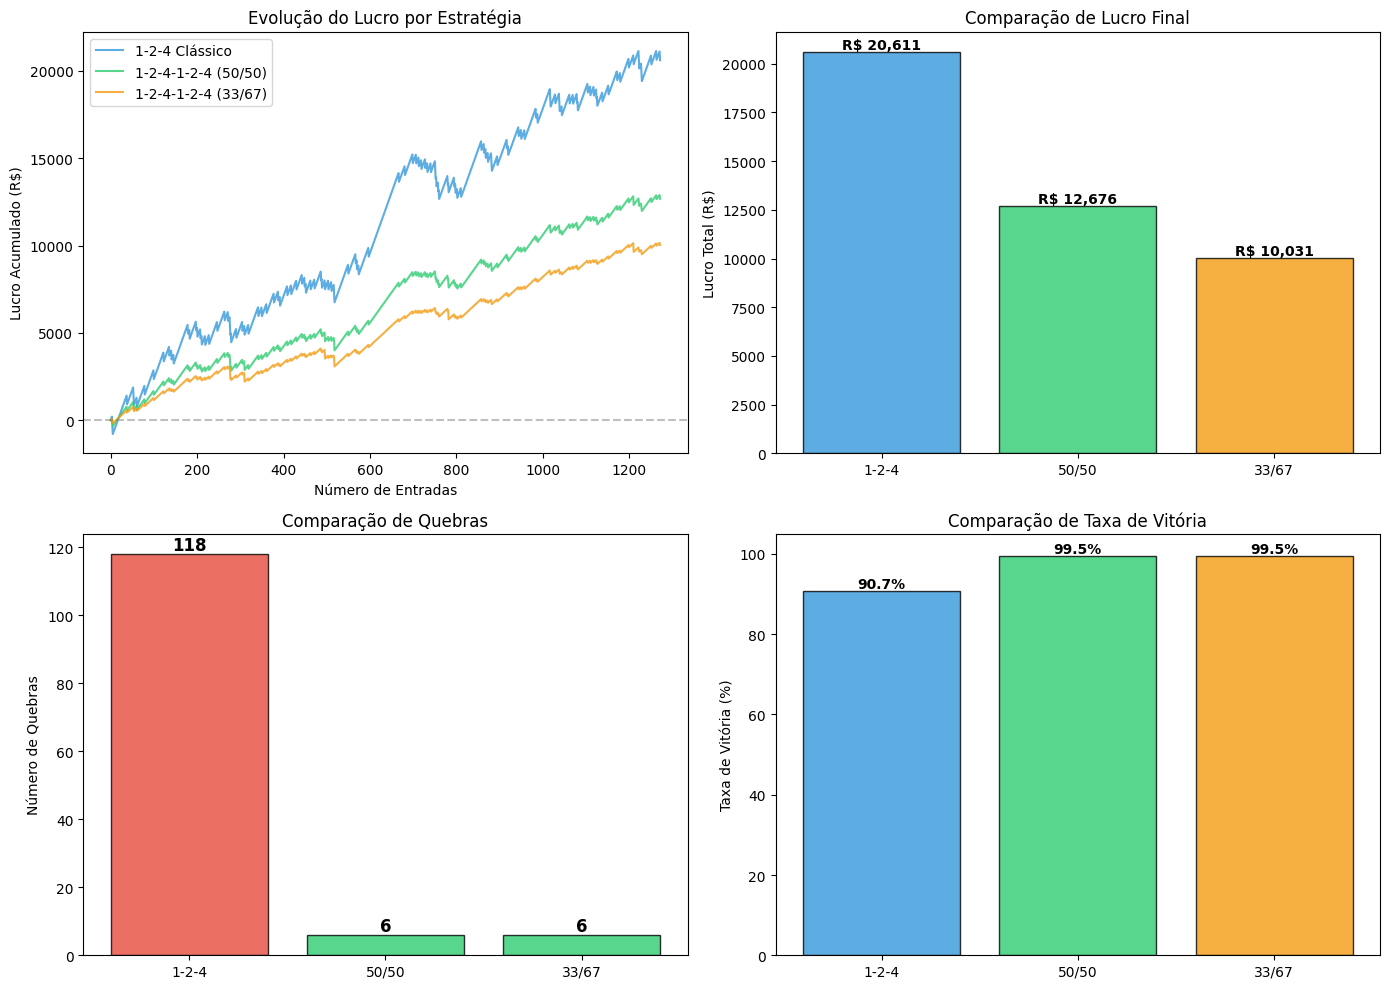


📁 Gráfico salvo: 01_comparacao_estrategias.png


In [5]:
# --- CÉLULA 5: VISUALIZAÇÃO ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cores = {'124': '#3498db', '5050': '#2ecc71', '3367': '#f39c12'}

# 1. Evolução do lucro
ax1 = axes[0, 0]
ax1.plot(res_124['historico'], label='1-2-4 Clássico', color=cores['124'], alpha=0.8)
ax1.plot(res_5050['historico'], label='1-2-4-1-2-4 (50/50)', color=cores['5050'], alpha=0.8)
ax1.plot(res_3367['historico'], label='1-2-4-1-2-4 (33/67)', color=cores['3367'], alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Número de Entradas')
ax1.set_ylabel('Lucro Acumulado (R$)')
ax1.set_title('Evolução do Lucro por Estratégia')
ax1.legend()

# 2. Lucro final
ax2 = axes[0, 1]
nomes = ['1-2-4', '50/50', '33/67']
lucros = [res_124['lucro'], res_5050['lucro'], res_3367['lucro']]
bars = ax2.bar(nomes, lucros, color=[cores['124'], cores['5050'], cores['3367']], 
               alpha=0.8, edgecolor='black')
ax2.set_ylabel('Lucro Total (R$)')
ax2.set_title('Comparação de Lucro Final')
for bar, lucro in zip(bars, lucros):
    ax2.annotate(f'R$ {lucro:,.0f}', xy=(bar.get_x() + bar.get_width()/2, lucro),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Quebras
ax3 = axes[1, 0]
quebras = [res_124['quebras'], res_5050['quebras'], res_3367['quebras']]
colors_quebras = ['#e74c3c' if q > 10 else '#2ecc71' for q in quebras]
bars = ax3.bar(nomes, quebras, color=colors_quebras, alpha=0.8, edgecolor='black')
ax3.set_ylabel('Número de Quebras')
ax3.set_title('Comparação de Quebras')
for bar, q in zip(bars, quebras):
    ax3.annotate(f'{q}', xy=(bar.get_x() + bar.get_width()/2, q),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. Taxa de vitória
ax4 = axes[1, 1]
taxas = [res_124['taxa_win'], res_5050['taxa_win'], res_3367['taxa_win']]
bars = ax4.bar(nomes, taxas, color=[cores['124'], cores['5050'], cores['3367']], 
               alpha=0.8, edgecolor='black')
ax4.set_ylabel('Taxa de Vitória (%)')
ax4.set_title('Comparação de Taxa de Vitória')
ax4.set_ylim(0, 105)
for bar, taxa in zip(bars, taxas):
    ax4.annotate(f'{taxa:.1f}%', xy=(bar.get_x() + bar.get_width()/2, taxa),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('01_comparacao_estrategias.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 01_comparacao_estrategias.png")

In [6]:
# --- CÉLULA 6: OTIMIZAÇÃO DE PARÂMETROS ---

print("="*70)
print("🔬 OTIMIZAÇÃO DE PARÂMETROS")
print("="*70)
print("\n⏳ Executando grid search... (pode demorar um pouco)")

# Grid search
gatilhos = [5, 6, 7, 8]
targets = [1.90, 1.95, 1.99, 2.00, 2.05, 2.10]

resultados = []

for gatilho in gatilhos:
    for target in targets:
        # 1-2-4 clássico
        res = simular_124_classico(multiplicadores, gatilho=gatilho, target=target)
        resultados.append({
            'estrategia': '1-2-4',
            'gatilho': gatilho,
            'target': target,
            'lucro': res['lucro'],
            'quebras': res['quebras'],
            'taxa_win': res['taxa_win'],
            'entradas': res['entradas']
        })
        
        # 1-2-4-1-2-4 (50/50)
        res = simular_124124(multiplicadores, gatilho=gatilho, target=target, divisao='50/50')
        resultados.append({
            'estrategia': '1-2-4-1-2-4',
            'gatilho': gatilho,
            'target': target,
            'lucro': res['lucro'],
            'quebras': res['quebras'],
            'taxa_win': res['taxa_win'],
            'entradas': res['entradas']
        })

df_resultados = pd.DataFrame(resultados)

print("\n✅ Otimização concluída!")
print(f"\nTotal de configurações testadas: {len(df_resultados)}")

🔬 OTIMIZAÇÃO DE PARÂMETROS

⏳ Executando grid search... (pode demorar um pouco)

✅ Otimização concluída!

Total de configurações testadas: 48


In [7]:
# --- CÉLULA 7: TOP CONFIGURAÇÕES ---

print("\n📊 TOP 10 CONFIGURAÇÕES POR LUCRO:")
top_lucro = df_resultados.nlargest(10, 'lucro')[['estrategia', 'gatilho', 'target', 'lucro', 'quebras', 'taxa_win']]
display(top_lucro)

print("\n📊 TOP 10 CONFIGURAÇÕES MAIS SEGURAS (≤10 quebras):")
df_seguro = df_resultados[df_resultados['quebras'] <= 10]
top_seguro = df_seguro.nlargest(10, 'lucro')[['estrategia', 'gatilho', 'target', 'lucro', 'quebras', 'taxa_win']]
display(top_seguro)


📊 TOP 10 CONFIGURAÇÕES POR LUCRO:


,estrategia,gatilho,target,lucro,quebras,taxa_win
22,1-2-4,6,2.10,25239.000000,136,89.299764
20,1-2-4,6,2.05,24222.607143,126,90.086546
16,1-2-4,6,1.99,20610.942857,118,90.715972
10,1-2-4,5,2.10,20416.714286,298,87.264957
14,1-2-4,6,1.95,20306.000000,109,91.424076
18,1-2-4,6,2.00,20266.428571,121,90.479937
12,1-2-4,6,1.90,19868.285714,98,92.289536
23,1-2-4-1-2-4,6,2.10,15861.607143,8,99.370574
11,1-2-4-1-2-4,5,2.10,15484.821429,24,98.974359
34,1-2-4,7,2.10,14889.714286,58,90.202703



📊 TOP 10 CONFIGURAÇÕES MAIS SEGURAS (≤10 quebras):


,estrategia,gatilho,target,lucro,quebras,taxa_win
23,1-2-4-1-2-4,6,2.10,15861.607143,8,99.370574
21,1-2-4-1-2-4,6,2.05,14886.392857,7,99.449253
17,1-2-4-1-2-4,6,1.99,12676.121429,6,99.527931
19,1-2-4-1-2-4,6,2.00,12674.285714,6,99.527931
15,1-2-4-1-2-4,6,1.95,12256.035714,5,99.606609
13,1-2-4-1-2-4,6,1.90,11691.785714,4,99.685287
35,1-2-4-1-2-4,7,2.10,9224.571429,2,99.662162
33,1-2-4-1-2-4,7,2.05,8752.339286,1,99.831081
31,1-2-4-1-2-4,7,2.00,8289.642857,0,100.000000
29,1-2-4-1-2-4,7,1.99,7941.382143,0,100.000000


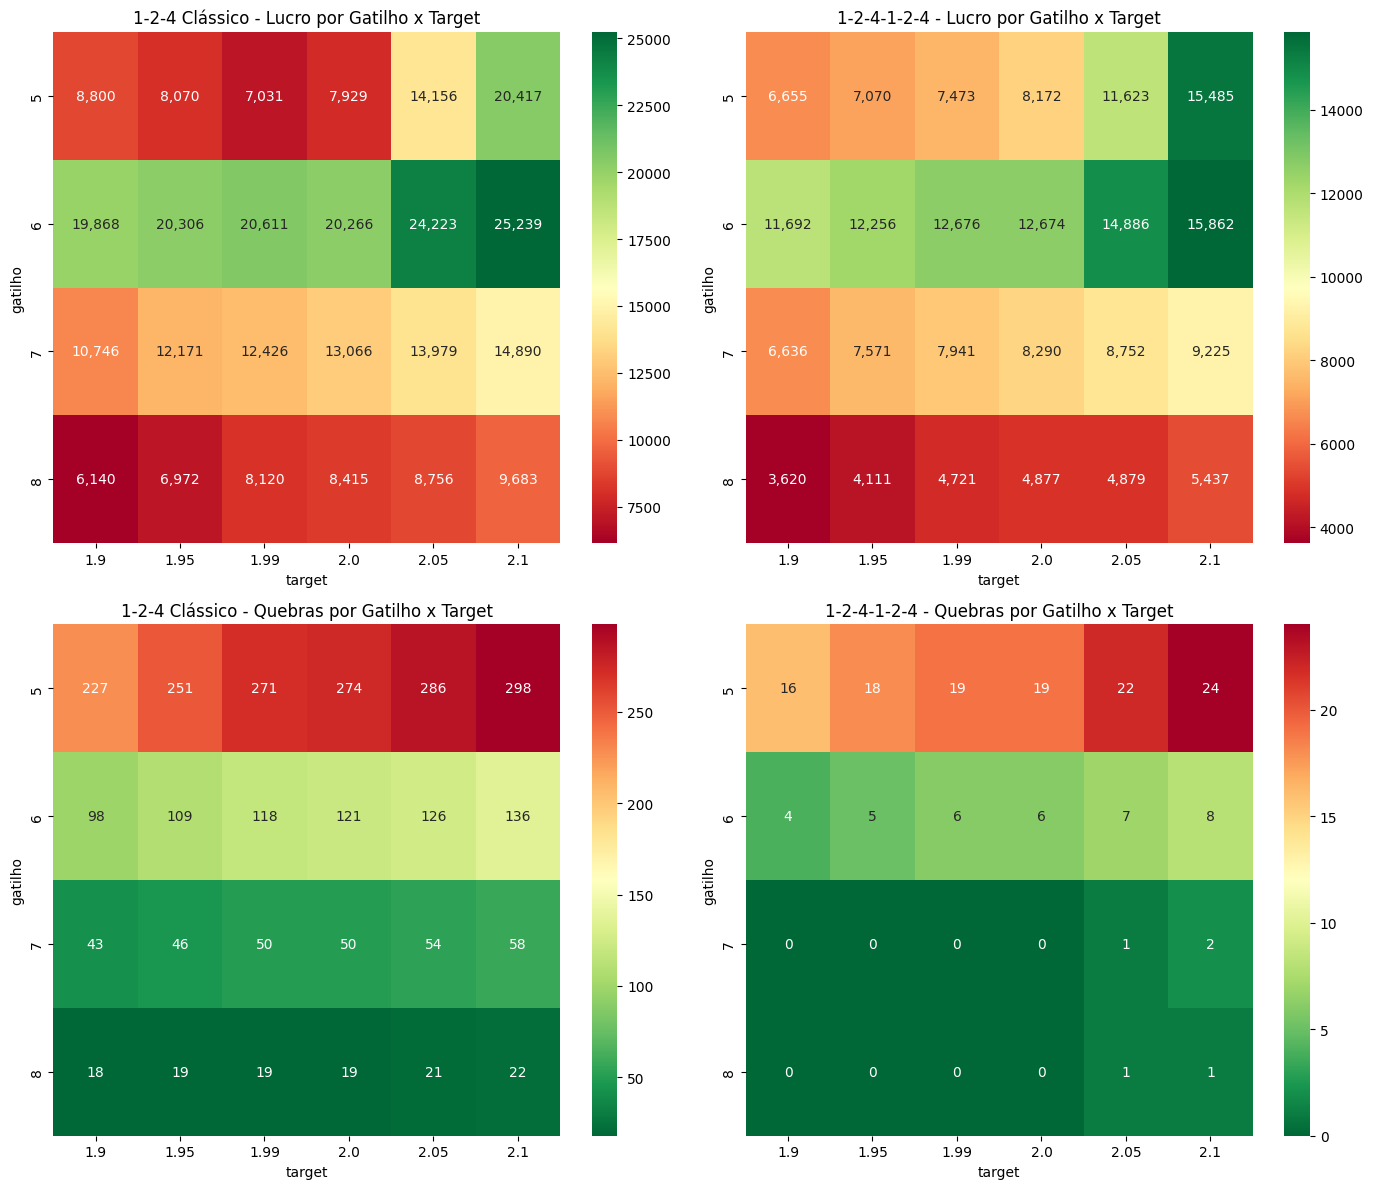


📁 Gráfico salvo: 02_heatmaps_otimizacao.png


In [8]:
# --- CÉLULA 8: HEATMAPS DE OTIMIZAÇÃO ---

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Filtrar por estratégia
df_124 = df_resultados[df_resultados['estrategia'] == '1-2-4']
df_124124 = df_resultados[df_resultados['estrategia'] == '1-2-4-1-2-4']

# Heatmap lucro - 1-2-4
ax1 = axes[0, 0]
pivot_124_lucro = df_124.pivot(index='gatilho', columns='target', values='lucro')
sns.heatmap(pivot_124_lucro, annot=True, fmt=',.0f', cmap='RdYlGn', ax=ax1)
ax1.set_title('1-2-4 Clássico - Lucro por Gatilho x Target')

# Heatmap lucro - 1-2-4-1-2-4
ax2 = axes[0, 1]
pivot_124124_lucro = df_124124.pivot(index='gatilho', columns='target', values='lucro')
sns.heatmap(pivot_124124_lucro, annot=True, fmt=',.0f', cmap='RdYlGn', ax=ax2)
ax2.set_title('1-2-4-1-2-4 - Lucro por Gatilho x Target')

# Heatmap quebras - 1-2-4
ax3 = axes[1, 0]
pivot_124_quebras = df_124.pivot(index='gatilho', columns='target', values='quebras')
sns.heatmap(pivot_124_quebras, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax3)
ax3.set_title('1-2-4 Clássico - Quebras por Gatilho x Target')

# Heatmap quebras - 1-2-4-1-2-4
ax4 = axes[1, 1]
pivot_124124_quebras = df_124124.pivot(index='gatilho', columns='target', values='quebras')
sns.heatmap(pivot_124124_quebras, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax4)
ax4.set_title('1-2-4-1-2-4 - Quebras por Gatilho x Target')

plt.tight_layout()
plt.savefig('02_heatmaps_otimizacao.png', dpi=150)
plt.show()

print("\n📁 Gráfico salvo: 02_heatmaps_otimizacao.png")

In [9]:
# --- CÉLULA 9: ANÁLISE DE RISCO (DRAWDOWN) ---

print("="*70)
print("📉 ANÁLISE DE RISCO - DRAWDOWN")
print("="*70)

def calcular_metricas_risco(historico):
    """Calcula métricas de risco."""
    serie = pd.Series(historico)
    pico = serie.cummax()
    drawdown = serie - pico
    max_drawdown = drawdown.min()
    
    retornos = serie.diff().dropna()
    volatilidade = retornos.std()
    sharpe = retornos.mean() / volatilidade if volatilidade > 0 else 0
    
    return {
        'max_drawdown': max_drawdown,
        'volatilidade': volatilidade,
        'sharpe': sharpe
    }

m_124 = calcular_metricas_risco(res_124['historico'])
m_5050 = calcular_metricas_risco(res_5050['historico'])
m_3367 = calcular_metricas_risco(res_3367['historico'])

print(f"\n{'Métrica':<20} {'1-2-4':>15} {'50/50':>15} {'33/67':>15}")
print("-"*70)
print(f"{'Lucro Final':<20} R$ {res_124['lucro']:>12,.2f} R$ {res_5050['lucro']:>12,.2f} R$ {res_3367['lucro']:>12,.2f}")
print(f"{'Max Drawdown':<20} R$ {m_124['max_drawdown']:>12,.2f} R$ {m_5050['max_drawdown']:>12,.2f} R$ {m_3367['max_drawdown']:>12,.2f}")
print(f"{'Volatilidade':<20} R$ {m_124['volatilidade']:>12,.2f} R$ {m_5050['volatilidade']:>12,.2f} R$ {m_3367['volatilidade']:>12,.2f}")
print(f"{'Sharpe Ratio':<20} {m_124['sharpe']:>15.3f} {m_5050['sharpe']:>15.3f} {m_3367['sharpe']:>15.3f}")

print(f"\n💡 CONCLUSÃO: 1-2-4-1-2-4 (50/50) tem melhor Sharpe Ratio ({m_5050['sharpe']:.3f})")
print(f"   = melhor relação risco/retorno!")

📉 ANÁLISE DE RISCO - DRAWDOWN

Métrica                        1-2-4           50/50           33/67
----------------------------------------------------------------------
Lucro Final          R$    20,610.94 R$    12,676.12 R$    10,031.18
Max Drawdown         R$    -2,546.55 R$    -1,208.42 R$    -1,023.69
Volatilidade         R$       165.21 R$        79.10 R$        53.69
Sharpe Ratio                   0.098           0.126           0.147

💡 CONCLUSÃO: 1-2-4-1-2-4 (50/50) tem melhor Sharpe Ratio (0.126)
   = melhor relação risco/retorno!


In [10]:
# --- CÉLULA 10: CONCLUSÕES ---

melhor = df_resultados.loc[df_resultados['lucro'].idxmax()]
melhor_seg = df_resultados[df_resultados['quebras'] <= 10].loc[
    df_resultados[df_resultados['quebras'] <= 10]['lucro'].idxmax()
]

print("="*70)
print("📋 CONCLUSÕES E RECOMENDAÇÕES")
print("="*70)

print(f"""
🏆 MELHOR CONFIGURAÇÃO POR LUCRO:
   Estratégia: {melhor['estrategia']}
   Gatilho: {int(melhor['gatilho'])} baixas
   Target: {melhor['target']:.2f}x
   Lucro: R$ {melhor['lucro']:,.2f}
   Quebras: {int(melhor['quebras'])}

🛡️ MELHOR CONFIGURAÇÃO SEGURA (≤10 quebras):
   Estratégia: {melhor_seg['estrategia']}
   Gatilho: {int(melhor_seg['gatilho'])} baixas
   Target: {melhor_seg['target']:.2f}x
   Lucro: R$ {melhor_seg['lucro']:,.2f}
   Quebras: {int(melhor_seg['quebras'])}

💡 RECOMENDAÇÕES:
   1. Usar divisão 50/50 ao invés de 33/67 (+{((res_5050['lucro']/res_3367['lucro'])-1)*100:.0f}% lucro)
   2. Considerar target 2.05x para maior lucro (mantendo randomização)
   3. Manter gatilho em 6 baixas (equilíbrio ideal)
   4. 1-2-4-1-2-4 tem melhor Sharpe Ratio (mais seguro)
""")

# Salvar resultados
df_resultados.to_csv('resultados_otimizacao.csv', index=False)
print("\n📁 Resultados salvos: resultados_otimizacao.csv")

📋 CONCLUSÕES E RECOMENDAÇÕES

🏆 MELHOR CONFIGURAÇÃO POR LUCRO:
   Estratégia: 1-2-4
   Gatilho: 6 baixas
   Target: 2.10x
   Lucro: R$ 25,239.00
   Quebras: 136

🛡️ MELHOR CONFIGURAÇÃO SEGURA (≤10 quebras):
   Estratégia: 1-2-4-1-2-4
   Gatilho: 6 baixas
   Target: 2.10x
   Lucro: R$ 15,861.61
   Quebras: 8

💡 RECOMENDAÇÕES:
   1. Usar divisão 50/50 ao invés de 33/67 (+26% lucro)
   2. Considerar target 2.05x para maior lucro (mantendo randomização)
   3. Manter gatilho em 6 baixas (equilíbrio ideal)
   4. 1-2-4-1-2-4 tem melhor Sharpe Ratio (mais seguro)


📁 Resultados salvos: resultados_otimizacao.csv
